# Nuclear Energy Economics: Two-Lecture Overview


## Learning objectives

By the end of these two class periods, students should be able to:

1. Distinguish power from energy and compute annual electricity production.
2. Explain capacity factor and why it strongly affects the economics of capital-intensive plants.
3. Distinguish fixed costs from variable costs.
4. Explain why future costs and revenues are discounted.
5. Compute a simple levelized cost of electricity (LCOE).
6. Explain why nuclear economics depends strongly on capital cost, financing, plant lifetime, and utilization.
7. Interpret the chapter's comparisons of LCOE, effective LCOE, and EROI across technologies.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.precision', 3)


# Lecture 1: Engineering Economics Foundation

Before discussing nuclear energy economics, let's discuss a small set of economic and energy-accounting tools. The goal is not to make you experts in finance; the goal is to help you understand what quantities appear in cost comparisons and why they matter.

## 1. Why economics matters

A reactor design can be technically impressive and still fail to be deployed if the electricity it produces is too expensive, too risky to finance, or poorly matched to the needs of the grid.

At this stage in your education, a useful way to define energy economics is:


$$
	\textrm{economic performance} \sim \frac{\textrm{useful electricity produced}}{\textrm{resources consumed to produce it}}.
$$

For a power plant, the resources include construction, financing, fuel, operations and maintenance, waste management, and decommissioning.

## 2. Power versus energy

I am sure you know these units, but economics makes the distinction especially important.

- **Power** is a rate of energy production: MW or GW.
- **Energy** is the accumulated amount produced: MWh, GWh, or TWh.

Utilities sell energy, but engineers design plants with a rated power.

In [29]:
# Example: annual energy from a 1000 MWe plant
plant_power_MW = 1000
hours_per_year = 8760

energy_if_full_power_MWh = plant_power_MW * hours_per_year
energy_if_full_power_TWh = energy_if_full_power_MWh / 1e6

print(f"A {plant_power_MW} MWe plant running at full power for one year produces:")
print(f"{energy_if_full_power_MWh:,.0f} MWh = {energy_if_full_power_TWh:.2f} TWh")

A 1000 MWe plant running at full power for one year produces:
8,760,000 MWh = 8.76 TWh


## 3. Capacity factor and availability

The **capacity factor** tells us how much electricity a plant actually produces compared with the maximum possible amount it could produce if it ran at full power all the time.

$$
CF = \frac{\textrm{actual energy produced}}{\textrm{rated power} \times \textrm{time}}.
$$

It is always less than 100% – either because the facility is not capable of maintaining its maximum output all the time, or because there is sometimes little or no demand for its output, or some combination of the two.
This is one of the most important concepts in electricity economics. A high-capital-cost plant needs to produce a lot of electricity to spread its fixed cost over many MWh.

**Availability** the ratio of the average output a facility is capable of to its maximum output.  Nuclear power stations and fuel fired power stations have high availability factors (~90%) – only less than 100% because of downtime for maintenance; wind, wave and solar power stations have much lower availability factors (typically ~10-30%, but see but...) because of the variability of their energy sources.

In [3]:
# Example: annual energy production at different capacity factors
capacity_factors = np.array([0.25, 0.50, 0.70, 0.90, 0.95])
energy_TWh = plant_power_MW * hours_per_year * capacity_factors / 1e6

cf_df = pd.DataFrame({
    "Capacity factor": capacity_factors,
    "Annual electricity (TWh)": energy_TWh
})
cf_df

,Capacity factor,Annual electricity (TWh)
0,0.25,2.190
1,0.50,4.380
2,0.70,6.132
3,0.90,7.884
4,0.95,8.322


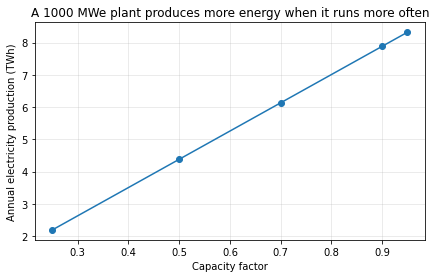

In [30]:
plt.figure(figsize=(7, 4))
plt.plot(cf_df["Capacity factor"], cf_df["Annual electricity (TWh)"], marker="o")
plt.xlabel("Capacity factor")
plt.ylabel("Annual electricity production (TWh)")
plt.title("A 1000 MWe plant produces more energy when it runs more often")
plt.grid(True, alpha=0.3)
plt.show()

## 4. Fixed costs versus variable costs

A helpful first model is to split costs into two categories.

**Fixed costs** are paid whether or not the plant produces electricity. Examples include construction cost, financing cost, licensing, staffing, security, and much of routine maintenance.

**Variable costs** scale more directly with electricity generation. Examples include fuel, some consumables, some waste handling costs, and some wear-related maintenance.

Nuclear plants tend to have high fixed costs and relatively low fuel costs. Natural gas plants tend to have lower construction costs but higher fuel-cost exposure.

In [5]:
# Simple comparison: how utilization affects fixed cost per MWh
annual_fixed_cost = 600e6   # dollars/year, illustrative
variable_cost = 8           # dollars/MWh, illustrative

cf_grid = np.linspace(0.2, 0.95, 16)
annual_mwh = plant_power_MW * hours_per_year * cf_grid
fixed_per_mwh = annual_fixed_cost / annual_mwh
total_cost_per_mwh = fixed_per_mwh + variable_cost

utilization_df = pd.DataFrame({
    "Capacity factor": cf_grid,
    "Fixed cost ($/MWh)": fixed_per_mwh,
    "Variable cost ($/MWh)": variable_cost,
    "Total cost ($/MWh)": total_cost_per_mwh
})
utilization_df.head()

,Capacity factor,Fixed cost ($/MWh),Variable cost ($/MWh),Total cost ($/MWh)
0,0.20,342.466,8,350.466
1,0.25,273.973,8,281.973
2,0.30,228.311,8,236.311
3,0.35,195.695,8,203.695
4,0.40,171.233,8,179.233


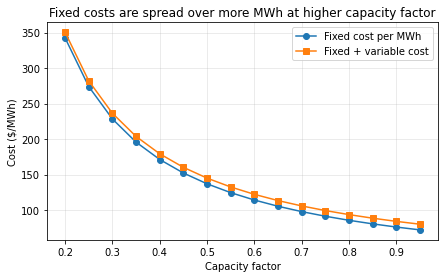

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(utilization_df["Capacity factor"], utilization_df["Fixed cost ($/MWh)"], marker="o", label="Fixed cost per MWh")
plt.plot(utilization_df["Capacity factor"], utilization_df["Total cost ($/MWh)"], marker="s", label="Fixed + variable cost")
plt.xlabel("Capacity factor")
plt.ylabel("Cost ($/MWh)")
plt.title("Fixed costs are spread over more MWh at higher capacity factor")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 5. Time value of money

A dollar today is worth more than a dollar received years from now. This matters strongly for nuclear plants because much of the spending occurs before revenue begins.

If a future amount \(FV\) is received \(n\) years from now and the discount rate is \(i\), its present value is

$$
PV = \frac{FV}{(1+i)^n}.
$$

A high discount rate penalizes technologies with large up-front construction costs and long construction times.

In [7]:
def present_value(future_value, rate, years):
    return future_value / (1 + rate)**years

future_value = 100
rates = [0.03, 0.05, 0.08]
years = np.arange(0, 31)

pv_df = pd.DataFrame({"Year": years})
for r in rates:
    pv_df[f"PV at {100*r:.0f}% ($)"] = present_value(future_value, r, years)

pv_df.head()

,Year,PV at 3% ($),PV at 5% ($),PV at 8% ($)
0,0,100.000,100.000,100.000
1,1,97.087,95.238,92.593
2,2,94.260,90.703,85.734
3,3,91.514,86.384,79.383
4,4,88.849,82.270,73.503


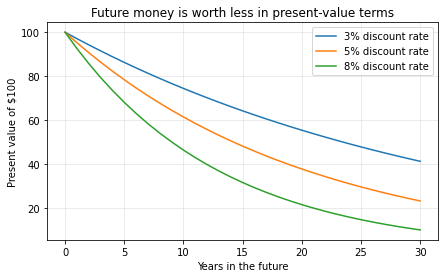

In [8]:
plt.figure(figsize=(7, 4))
for r in rates:
    plt.plot(pv_df["Year"], pv_df[f"PV at {100*r:.0f}% ($)"], label=f"{100*r:.0f}% discount rate")
plt.xlabel("Years in the future")
plt.ylabel("Present value of $100")
plt.title("Future money is worth less in present-value terms")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 6. First-pass LCOE

The **levelized cost of electricity** is the average cost of producing one MWh over the plant lifetime. At the simplest level,

$$
LCOE \approx \frac{\textrm{lifetime cost}}{\textrm{lifetime electricity produced}}.
$$

A more complete version accounts for discounting and annualizes capital costs, but this simple ratio is enough to build intuition.

In [9]:
# Simple lifetime LCOE calculation
construction_cost = 6e9      # dollars
fuel_cost = 1e9              # dollars
om_cost = 2e9                # dollars
decommissioning_cost = 1e9   # dollars

total_lifetime_cost = construction_cost + fuel_cost + om_cost + decommissioning_cost
lifetime_electricity_MWh = 200e6

simple_lcoe = total_lifetime_cost / lifetime_electricity_MWh

print(f"Total lifetime cost: ${total_lifetime_cost/1e9:.1f} billion")
print(f"Lifetime electricity: {lifetime_electricity_MWh/1e6:.0f} million MWh")
print(f"Simple LCOE: ${simple_lcoe:.1f}/MWh")

Total lifetime cost: $10.0 billion
Lifetime electricity: 200 million MWh
Simple LCOE: $50.0/MWh


In [10]:
# Sensitivity: what happens if the same plant produces less lifetime electricity?
lifetime_energy_values = np.array([120, 150, 200, 250, 300]) * 1e6
lcoe_values = total_lifetime_cost / lifetime_energy_values

simple_lcoe_df = pd.DataFrame({
    "Lifetime electricity (million MWh)": lifetime_energy_values / 1e6,
    "Simple LCOE ($/MWh)": lcoe_values
})
simple_lcoe_df

,Lifetime electricity (million MWh),Simple LCOE ($/MWh)
0,120.0,83.333
1,150.0,66.667
2,200.0,50.000
3,250.0,40.000
4,300.0,33.333


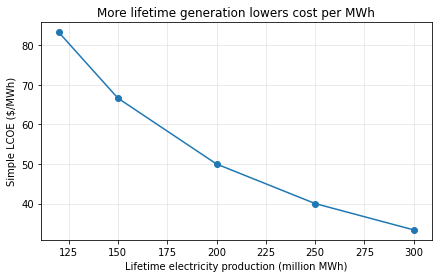

In [11]:
plt.figure(figsize=(7, 4))
plt.plot(simple_lcoe_df["Lifetime electricity (million MWh)"], simple_lcoe_df["Simple LCOE ($/MWh)"], marker="o")
plt.xlabel("Lifetime electricity production (million MWh)")
plt.ylabel("Simple LCOE ($/MWh)")
plt.title("More lifetime generation lowers cost per MWh")
plt.grid(True, alpha=0.3)
plt.show()

## Lecture 1 takeaways

- Power is the rate of production; energy is the accumulated product that is sold.
- Capacity factor strongly affects annual and lifetime electricity production.
- Capital-intensive plants need high utilization to spread fixed costs over many MWh.
- Discounting matters because construction costs occur early and revenues occur later.
- LCOE is a useful first metric, but it does not capture every aspect of grid value.

The next lecture applies these tools to nuclear power and to the discussion of LCOE, effective LCOE, and EROI in Chapter 15 of Lee's book.

# Lecture 2: Nuclear Energy Economics and Technology Comparisons

## 1. Nuclear LCOE: moving from simple ratios to annualized costs

The **levelized cost of electricity** is an average cost per unit electricity produced over the life of a plant. In its simplest form, it asks:

If all capital, financing, operations, maintenance, and fuel costs were spread over all lifetime MWh, what would each MWh cost?

A useful simplified form is

$$
\mathrm{LCOE} = \frac{\mathrm{annualized\ capital\ cost}+\mathrm{fixed\ O\&M}}{\mathrm{annual\ electricity\ generation}} + \mathrm{variable\ O\&M}+\mathrm{fuel}.
$$

This is a good starting point, but it does **not** fully measure whether electricity is available when the grid needs it.


In [13]:
def capital_recovery_factor(rate, years):
    """Return the capital recovery factor for annualizing an up-front cost."""
    r = rate
    n = years
    return r * (1 + r)**n / ((1 + r)**n - 1)


def simple_lcoe(overnight_cost_per_kw, fixed_om_per_kw_yr, variable_om_per_mwh,
                fuel_per_mwh, capacity_factor, rate=0.07, lifetime_yr=40):
    """Simplified LCOE in $/MWh."""
    crf = capital_recovery_factor(rate, lifetime_yr)
    annualized_capital = overnight_cost_per_kw * crf
    annual_generation_per_kw = 8760 * capacity_factor / 1000  # MWh per kW-year
    fixed_component = (annualized_capital + fixed_om_per_kw_yr) / annual_generation_per_kw
    return fixed_component + variable_om_per_mwh + fuel_per_mwh

# A rough illustrative nuclear plant case, chosen for classroom arithmetic.
example = {
    "overnight_cost_per_kw": 7000,
    "fixed_om_per_kw_yr": 130,
    "variable_om_per_mwh": 2,
    "fuel_per_mwh": 7,
    "rate": 0.07,
    "lifetime_yr": 40,
}

capacity_factors = np.array([0.90, 0.75, 0.60, 0.50])
lcoe_values = [simple_lcoe(capacity_factor=cf, **example) for cf in capacity_factors]

lcoe_df = pd.DataFrame({
    "Capacity factor": capacity_factors,
    "LCOE ($/MWh)": lcoe_values
})
lcoe_df


,Capacity factor,LCOE ($/MWh)
0,0.90,92.088
1,0.75,108.705
2,0.60,133.632
3,0.50,158.558


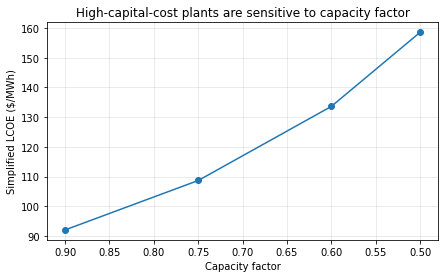

In [14]:
plt.figure(figsize=(7, 4))
plt.plot(lcoe_df["Capacity factor"], lcoe_df["LCOE ($/MWh)"], marker="o")
plt.gca().invert_xaxis()
plt.xlabel("Capacity factor")
plt.ylabel("Simplified LCOE ($/MWh)")
plt.title("High-capital-cost plants are sensitive to capacity factor")
plt.grid(True, alpha=0.3)
plt.show()


### Discussion

For a capital-intensive plant, reducing the capacity factor means that the fixed costs are spread over fewer MWh. This is one reason nuclear economics depends strongly on high availability, reliable operation, refueling outage length, and market rules that compensate firm capacity.


## 2. LCOE versus effective LCOE

The excerpt emphasizes that nominal LCOE is not the whole story. Electricity sources differ in how dispatchable and dependable they are. The figure below compares nominal LCOE with an **effective LCOE** estimate for Texas and Germany. The main qualitative lesson is that the grid-system context can dramatically change the apparent cost of variable sources.

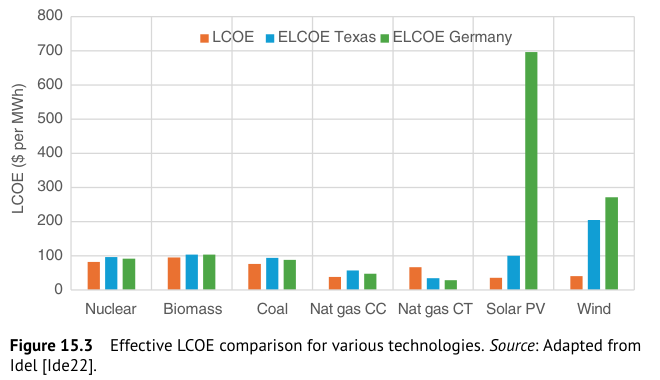

Lee also notes that including storage can make the effective cost of solar PV much higher: the excerpt reports storage-inclusive solar PV values of about `$1,380/MWh` in Germany and `$413/MWh` in Texas. The details depend on assumptions about storage and dispatch, so the values should be treated as an illustration of system-level effects, not as universal constants.


In [15]:
# Approximate values read from Figure 15.3 for classroom discussion.
# These are intentionally labeled approximate because the source is a plotted figure, not a data table.
elcoe_df = pd.DataFrame({
    "Technology": ["Nuclear", "Biomass", "Coal", "Nat gas CC", "Nat gas CT", "Solar PV", "Wind"],
    "LCOE": [80, 90, 75, 35, 65, 35, 40],
    "ELCOE Texas": [90, 100, 95, 55, 35, 95, 200],
    "ELCOE Germany": [90, 100, 90, 45, 25, 700, 270],
})

elcoe_df["Texas / nominal"] = elcoe_df["ELCOE Texas"] / elcoe_df["LCOE"]
elcoe_df["Germany / nominal"] = elcoe_df["ELCOE Germany"] / elcoe_df["LCOE"]
elcoe_df


,Technology,LCOE,ELCOE Texas,ELCOE Germany,Texas / nominal,Germany / nominal
0,Nuclear,80,90,90,1.125,1.125
1,Biomass,90,100,100,1.111,1.111
2,Coal,75,95,90,1.267,1.200
3,Nat gas CC,35,55,45,1.571,1.286
4,Nat gas CT,65,35,25,0.538,0.385
5,Solar PV,35,95,700,2.714,20.000
6,Wind,40,200,270,5.000,6.750


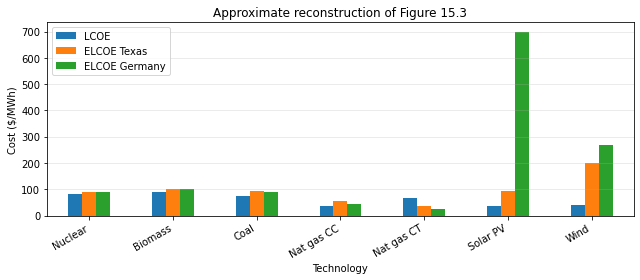

In [16]:
plot_df = elcoe_df.set_index("Technology")[["LCOE", "ELCOE Texas", "ELCOE Germany"]]
ax = plot_df.plot(kind="bar", figsize=(9, 4))
ax.set_ylabel("Cost ($/MWh)")
ax.set_title("Approximate reconstruction of Figure 15.3")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


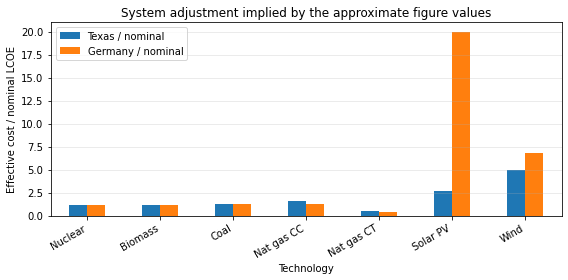

In [17]:
ratio_df = elcoe_df.set_index("Technology")[["Texas / nominal", "Germany / nominal"]]
ax = ratio_df.plot(kind="bar", figsize=(8, 4))
ax.set_ylabel("Effective cost / nominal LCOE")
ax.set_title("System adjustment implied by the approximate figure values")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### Discussion prompts

- Why might the same technology have different effective costs in Texas and Germany?
- Why does dispatchability matter even if two plants have the same nominal LCOE?
- What additional assumptions would be needed to compare firm nuclear generation with solar plus storage?


## 3. EROI: energy return on investment

The **energy return on investment** is

$$
\mathrm{EROI} = \frac{\mathrm{lifetime\ energy\ output}}{\mathrm{lifetime\ energy\ input}}.
$$

This measures how much usable energy a technology produces compared with the energy required to build, operate, fuel, and decommission it.


In [23]:
eroi_df = pd.DataFrame({
    "Technology": ["Nuclear", "Nat gas CC", "Solar PV", "Wind", "Coal"],
    "Installed capacity (kW)": [1.34e6, 8.20e5, 0.0928, 1.50e3, 5.09e5],
    "Full-load hours per year": [8000, 7500, 1000, 2000, 7500],
    "Lifetime (yr)": [60, 35, 25, 20, 50],
    "Energy output (TJ)": [2.32e6, 7.75e5, 0.00835, 216, 6.87e5],
    "Energy input (TJ)": [3.09e4, 2.69e4, 0.00217, 13.2, 2.40e4],
    "Construction (TJ)": [4.05e3, 470, 0.00177, 12.9, 1.97e3],
    "O&M (TJ)": [6.90e3, 255, 0.0004, 0.3, 7.40e3],
    "Fuel (TJ)": [1.88e4, 2.61e4, 0, 0, 1.45e4],
    "Decommissioning (TJ)": [1.15e3, 30, 0, 0, 91],
})

eroi_df["Calculated EROI"] = eroi_df["Energy output (TJ)"] / eroi_df["Energy input (TJ)"]
eroi_df[["Technology", "Energy output (TJ)", "Energy input (TJ)", "Calculated EROI"]]


,Technology,Energy output (TJ),Energy input (TJ),Calculated EROI
0,Nuclear,2.320e+06,30900.000,75.081
1,Nat gas CC,7.750e+05,26900.000,28.810
2,Solar PV,8.350e-03,0.002,3.848
3,Wind,2.160e+02,13.200,16.364
4,Coal,6.870e+05,24000.000,28.625


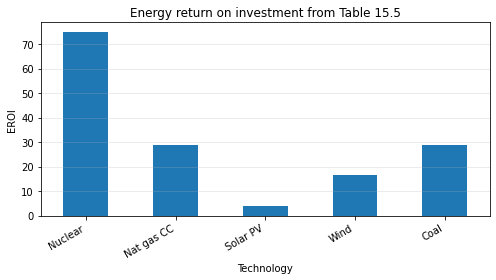

In [24]:
ax = eroi_df.set_index("Technology")["Calculated EROI"].plot(kind="bar", figsize=(7, 4))
ax.set_ylabel("EROI")
ax.set_title("Energy return on investment from Table 15.5")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


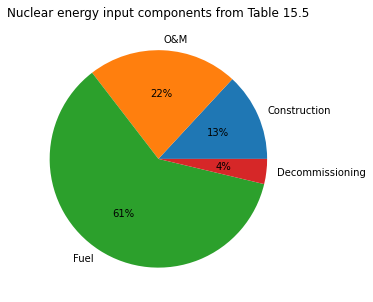

In [25]:
# Break down the reported nuclear energy input.
nuclear = eroi_df[eroi_df["Technology"] == "Nuclear"].iloc[0]
components = pd.Series({
    "Construction": nuclear["Construction (TJ)"],
    "O&M": nuclear["O&M (TJ)"],
    "Fuel": nuclear["Fuel (TJ)"],
    "Decommissioning": nuclear["Decommissioning (TJ)"],
})

ax = components.plot(kind="pie", figsize=(5, 5), autopct="%1.0f%%")
ax.set_ylabel("")
ax.set_title("Nuclear energy input components from Table 15.5")
plt.show()


### Discussion

The excerpt notes that much of the nuclear energy input in Table 15.5 comes from fuel enrichment, especially if gaseous diffusion is assumed. This is an important connection between **fuel-cycle technology** and **energy economics**. Moving from gaseous diffusion to gas centrifuge enrichment can substantially reduce the energy input.


## 4. Simple calculation: effect of nuclear plant lifetime on EROI

Typically, we assume a 60-year nuclear plant lifetime. If the plant lifetime were instead 40 years, the EROI would decrease to roughly 50. Let us reproduce that estimate using a simple proportional model.


In [26]:
nuclear_output_60 = 2.32e6  # TJ, from Table 15.5
nuclear_input = 3.09e4      # TJ, from Table 15.5

lifetimes = np.array([40, 50, 60, 80])
outputs = nuclear_output_60 * lifetimes / 60
simple_eroi = outputs / nuclear_input

life_df = pd.DataFrame({
    "Lifetime (yr)": lifetimes,
    "Output estimate (TJ)": outputs,
    "EROI estimate": simple_eroi,
})
life_df


,Lifetime (yr),Output estimate (TJ),EROI estimate
0,40,1.547e+06,50.054
1,50,1.933e+06,62.567
2,60,2.320e+06,75.081
3,80,3.093e+06,100.108


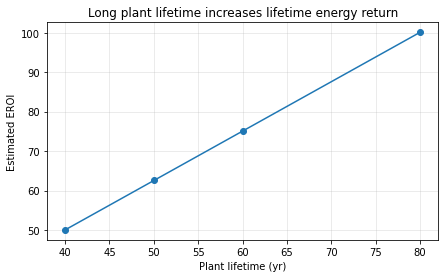

In [27]:
plt.figure(figsize=(7, 4))
plt.plot(life_df["Lifetime (yr)"], life_df["EROI estimate"], marker="o")
plt.xlabel("Plant lifetime (yr)")
plt.ylabel("Estimated EROI")
plt.title("Long plant lifetime increases lifetime energy return")
plt.grid(True, alpha=0.3)
plt.show()


This simple calculation keeps the total energy input fixed while scaling the energy output with lifetime. A more detailed model would separate one-time inputs, annual O&M inputs, fuel inputs, uprates, outages, and decommissioning.


## 5. Simple calculation: what energy input corresponds to EROI = 105?

The excerpt suggests that using gas centrifuge enrichment could possibly raise nuclear EROI as high as about 105. If the same lifetime output is retained, the required total energy input would be:


In [28]:
target_eroi = 105
required_input = nuclear_output_60 / target_eroi
reduction = nuclear_input - required_input
percent_reduction = 100 * reduction / nuclear_input

pd.DataFrame({
    "Case": ["Table 15.5 nuclear", "Hypothetical EROI = 105"],
    "Energy output (TJ)": [nuclear_output_60, nuclear_output_60],
    "Energy input (TJ)": [nuclear_input, required_input],
    "EROI": [nuclear_output_60 / nuclear_input, target_eroi],
})


,Case,Energy output (TJ),Energy input (TJ),EROI
0,Table 15.5 nuclear,2.320e+06,30900.000,75.081
1,Hypothetical EROI = 105,2.320e+06,22095.238,105.000


In [13]:
print(f"Energy input reduction needed: {reduction:,.0f} TJ")
print(f"Percent reduction in total energy input: {percent_reduction:.1f}%")


Energy input reduction needed: 8,805 TJ
Percent reduction in total energy input: 28.5%


### Interpretation

This does not prove that a particular plant will achieve EROI = 105. It simply shows the scale of energy-input reduction implied by that target. It also gives students a concrete way to connect enrichment technology, fuel cycle assumptions, and reactor economics.


## 6. Synthesis: connecting economics to reactor technology

Students have already studied reactor technologies, so this is a good place to connect economics back to engineering design.

| Engineering feature | Economic connection |
|---|---|
| High capacity factor | Fixed costs are spread over more MWh. |
| Long plant lifetime | Increases lifetime output and can improve EROI. |
| High thermal efficiency | More electricity for the same reactor heat rate. |
| Short refueling outages | Improves availability and revenue. |
| Low fuel cost sensitivity | Nuclear economics are often dominated by capital and fixed O&M rather than fuel price. |
| Dispatchability / firm capacity | Provides grid value not fully captured by nominal LCOE. |
| Fuel-cycle technology | Enrichment and fuel fabrication choices affect energy input and cost. |


## Key takeaways

- LCOE is useful, but it is not the full economic story.
- For nuclear plants, capital cost, financing, lifetime, and capacity factor are especially important.
- Effective/system-adjusted cost metrics attempt to include the fact that not all MWh have the same grid value.
- EROI provides a complementary energy-accounting view.
- Nuclear power's high capacity factor, long lifetime, and high EROI are major economic strengths, but construction cost and schedule remain central challenges.
